# Co-location check: chunk tile vs the full field

1. **Load a co-location result** — the final parquet if it exists, else
   assembled from the per-property checkpoint fragments.
2. **Compute both sides here** — the tile from its CHUNKS store, and the global
   reference for the same snapshot — so it does not matter how far a production
   run has got.
3. **Compare** for the fronts they share.

The checkpoint fragments hold *only* their own property's columns — no `flabel`,
no `npix` — because they are written positionally alongside the run's label
array. The key is rebuilt below from the label map; a fragment whose row count
disagrees with the front count came from a run with a different `min_npix` or
label map, and the assert catches it.

A surviving `colocate_ckpt_*` next to a finished parquet is litter from
`shutil.rmtree` failing on a network filesystem. Delete it before re-running
that timestamp with clobber.

In [1]:
%matplotlib inline
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT     = '/mnt/tank/Oceanography/data/OGCM/LLC/Fronts'
FRONTS   = f'{ROOT}/V5/SURF'
RUN_ID   = 'v2_2_01'                  # the build_v5 run that made the fronts
FIND_CFG = 'D'
RUN_TAG  = f'{RUN_ID}_bfronts'        # how the products are named

TS_DIR   = f'{FRONTS}/20111204_000000'

print(sorted(os.listdir(TS_DIR)))
ck = f'{TS_DIR}/colocate_ckpt_{RUN_TAG}'
if os.path.isdir(ck):
    print(f'\n{len(os.listdir(ck))} checkpoint fragments: {sorted(os.listdir(ck))}')
FIGDIR = os.path.expanduser('~/gradb2_check_figs')
os.makedirs(FIGDIR, exist_ok=True)


['LLC4320_2011-12-04T00_00_00_gradb2_v2_2_01.nc', 'LLC4320_2011-12-04T00_00_00_gradb2_v2_2_01_recheck.nc', 'LLC4320_2011-12-04T00_00_00_v2_2_01_bfronts.npy', 'front_index_20111204T00_00_00_v2_2_01_bfronts.parquet', 'front_properties_20111204T00_00_00_v2_2_01_bfronts.parquet', 'global_front_geometry_20111204T00_00_00_v2_2_01_bfronts.parquet', 'labeled_fronts_global_20111204T00_00_00_v2_2_01_bfronts.npy', 'metadata_20111204T00_00_00_v2_2_01_bfronts.json', 'metadata_properties_20111204T00_00_00_v2_2_01_bfronts.json']


## 1. Load one timestamp's co-location

In [2]:
def load_colocation(ts_dir, run_tag, min_npix=1):
    """Final parquet if present, else assemble the checkpoint fragments.

    Returns (df, source).  Fragments carry only their own property columns, so
    flabel/npix are recomputed from the label map and concatenated on.  The
    label map is looked up one level up when *ts_dir* is a subdirectory (a tile
    or nb_check output).
    """
    final = glob.glob(f'{ts_dir}/front_properties_*_{run_tag}.parquet')
    if final:
        return pd.read_parquet(final[0]), 'final parquet'

    frags = sorted(glob.glob(f'{ts_dir}/colocate_ckpt_{run_tag}/*.parquet'))
    if not frags:
        raise FileNotFoundError(f'no result and no fragments in {ts_dir}')

    lab = (glob.glob(f'{ts_dir}/labeled_fronts_global_*_{run_tag}.npy')
           or glob.glob(f'{ts_dir}/../labeled_fronts_global_*_{run_tag}.npy'))
    labels, counts = np.unique(np.load(lab[0]), return_counts=True)
    keep = (labels > 0) & (counts >= min_npix)
    key = pd.DataFrame({'flabel': labels[keep], 'npix': counts[keep]})

    parts = [key]
    for f in frags:
        d = pd.read_parquet(f)
        assert len(d) == len(key), (
            f'{os.path.basename(f)}: {len(d)} rows vs {len(key)} fronts -- '
            'fragment came from a run with a different label map or min_npix')
        parts.append(d)
    return pd.concat(parts, axis=1), f'{len(frags)} checkpoint fragments'


df, src = load_colocation(TS_DIR, RUN_TAG)
print(f'{len(df):,} fronts from {src},  {len(df.columns)} columns')
df.head()

133,143 fronts from final parquet,  182 columns


,flabel,npix,gradb2_mean,gradb2_std,gradb2_median,gradb2_p25,gradb2_p75,gradb2_p90,gradsalt2_mean,gradsalt2_std,...,v_ekman_median,v_ekman_p25,v_ekman_p75,v_ekman_p90,oceQnet_mean,oceQnet_std,oceQnet_median,oceQnet_p25,oceQnet_p75,oceQnet_p90
0,1,509,4.204871e-13,5.380876e-13,2.905819e-13,9.894824e-14,5.311866e-13,8.570123e-13,7.254287e-09,8.844942e-09,...,-0.084645,-0.100949,-0.072697,-0.065347,-341.261640,414.068584,-294.539078,-299.019653,-282.366035,-251.972995
1,2,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,13,8.807702e-14,0.000000e+00,8.807702e-14,8.807702e-14,8.807702e-14,8.807702e-14,1.392594e-09,0.000000e+00,...,-0.064093,-0.064093,-0.064093,-0.064093,-226.425400,0.000000,-226.425400,-226.425400,-226.425400,-226.425400
4,5,138,2.500241e-13,2.364060e-13,1.448770e-13,9.580889e-14,3.360653e-13,5.890122e-13,4.249566e-09,3.879895e-09,...,-0.194932,-0.197429,-0.156486,-0.115227,-176.572698,147.050774,-216.692627,-221.187683,-213.789108,-192.701123


## 2. Sanity: how much is NaN, and why

% of fronts with no valid pixels, per property:
strain_mag_mean            17.06
divergence_mean            17.06
strain_n_mean              17.06
strain_s_mean              17.06
relative_vorticity_mean    17.06
rossby_number_mean         17.06
okubo_weiss_mean           17.06
ekman_pumping_mean         17.06
wind_stress_curl_mean      17.06
gradtheta2_mean            17.05
turner_angle_mean          17.05
gradrho2_mean              17.05
gradeta2_mean              17.05
gradb2_mean                17.05
U_mean                     17.05
V_mean                     17.05
gradsalt2_mean             17.05
oceTAUX_mean               17.05
v_ekman_mean               17.05
u_ekman_mean               17.05
oceTAUY_mean               17.05
SIarea_mean                17.05
buoyancy_mean              17.05
density_mean               17.05
Theta_mean                 17.05
coriolis_f_mean            17.05
Eta_mean                   17.05
Salt_mean                  17.05
W_mean                     1

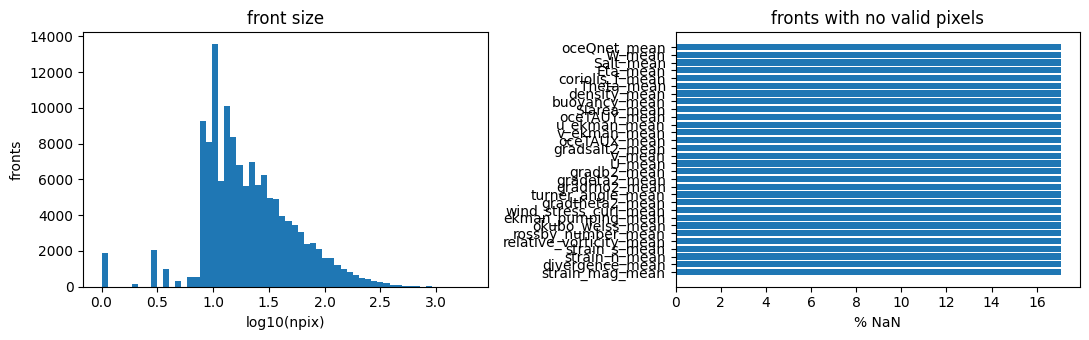

In [3]:
means = df.filter(like='_mean')
nan_pct = (means.isna().mean() * 100).sort_values(ascending=False)
print('% of fronts with no valid pixels, per property:')
print(nan_pct.round(2).to_string())

print(f'\nnpix: min={df.npix.min()}  median={df.npix.median():.0f}  '
      f'max={df.npix.max():,}  total front pixels={df.npix.sum():,}')
print(f'single-pixel fronts: {(df.npix == 1).sum():,} '
      f'({100 * (df.npix == 1).mean():.1f}%)  <- these drive the '
      '"Degrees of freedom <= 0" warnings')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(np.log10(df.npix), bins=60)
ax[0].set(xlabel='log10(npix)', ylabel='fronts', title='front size')
ax[1].barh(nan_pct.index, nan_pct.values)
ax[1].set(xlabel='% NaN', title='fronts with no valid pixels')
fig.tight_layout()

A high NaN rate on `SIarea` is the ice mask working. A high rate on a field that
should be everywhere (`density`, `gradb2`) means land, or something wrong.

## 3. Compute both sides here

`2012-07-04 12:00:00` is the only date the 100-timestep global run and the
Monterey chunk store share, and `density` / `gradb2` are the only two properties
in both — so that snapshot and those two fields are the whole comparison.

Both sides are computed here, so it does not matter how far the production run
has got. The global side writes to a `nb_check/` subdirectory with its own
checkpoint cache, so it cannot collide with a run in flight. Neither side is
ice-masked, which matches the chunk path exactly (and Monterey has no ice).

First run costs: the rect↔face lookup maps get built (three 13x4320x4320 index
arrays, tens of seconds and a few GB, then cached for the session), and each
property is read or computed from S3. `clobber=False`, so re-running is cheap.

In [4]:
from fronts.llc import io as llc_io
from fronts.llc import tiles as llc_tiles
from fronts.properties.run import colocate_fronts, colocate_tile

CHUNK      = 'monterey_bay'
TS         = '2012-07-04T12_00_00'
CMP_DIR    = f'{FRONTS}/20120704_120000'
SHARED     = ['density', 'gradb2']
GLOBAL_OUT = f'{CMP_DIR}/nb_check'
CONFIG     = '../../runs/prototypes/one_full/run_v5_100_timesteps.yaml'

llc_io.set_fronts_path(ROOT)
llc_io.set_run_layout('V5/SURF', file_tag=RUN_ID)

# --- tile side: fields computed from the chunk store ---
tile = llc_tiles.tile_from_chunk_store(CHUNK)
print(f'{CHUNK}: tile {tile.tile_idx}, face {tile.face_idx}, '
      f'rect j={tile.rect_j_slice.start} i={tile.rect_i_slice.start}, '
      f'face-local j={tile.j_face_slice.start} i={tile.i_face_slice.start}\n')

colocate_tile(TS, FIND_CFG, RUN_ID,
              property_names=SHARED, tile=tile,
              percentiles=[90], clobber=False,
              loader=llc_tiles.chunk_loader(CHUNK, TS))

monterey_bay: tile 330, face 10, rect j=9360 i=12960, face-local j=0 i=2880

Properties file /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V5/SURF/20120704_120000/tile330/front_properties_20120704T12_00_00_v2_2_01_bfronts.parquet exists and clobber is False. Returning


In [5]:
# --- global side: same two fields, straight from the global zarr stores ---
colocate_fronts(TS, FIND_CFG, RUN_ID,
                property_names=SHARED,
                output_dir=GLOBAL_OUT,
                percentiles=[90], skip_missing=True, clobber=False,
                config_file=CONFIG, source='zarr', ice_mask=False)

Properties file /mnt/tank/Oceanography/data/OGCM/LLC/Fronts/V5/SURF/20120704_120000/nb_check/front_properties_20120704T12_00_00_v2_2_01_bfronts.parquet exists and clobber is False. Returning


## 4. Compare

Fronts wholly inside the tile (`npix_tile == npix_glob`) are the fair
comparison — a clipped front's tile statistics describe only its clipped part.

Expect close but not identical: the global fields come from the full face with
grid connections, the tile fields from a single-face chunk with
`use_connections=False`, so stencil-based quantities differ near the rim.

In [6]:
tile_dir = f'{CMP_DIR}/tile{tile.tile_idx:03d}'

g, gsrc = load_colocation(GLOBAL_OUT, RUN_TAG)
t, tsrc = load_colocation(tile_dir, RUN_TAG)
print(f'global: {len(g):,} fronts ({gsrc})')
print(f'tile  : {len(t):,} fronts ({tsrc})')

m = g.merge(t, on='flabel', suffixes=('_glob', '_tile'))
inside = m[m.npix_tile == m.npix_glob]
print(f'\nfronts in both: {len(m):,}   wholly inside the tile: {len(inside):,} '
      f'({100 * len(inside) / max(len(m), 1):.0f}%)')

global: 139,719 fronts (final parquet)
tile  : 393 fronts (final parquet)

fronts in both: 393   wholly inside the tile: 361 (92%)


In [7]:
if not len(inside):
    print('every shared front is clipped by the tile edge; nothing fair to compare')
else:
    fig, axes = plt.subplots(1, len(SHARED), figsize=(5 * len(SHARED), 4.5))
    axes = np.atleast_1d(axes)

    for ax, prop in zip(axes, SHARED):
        a = inside[f'{prop}_mean_glob'].values
        b = inside[f'{prop}_mean_tile'].values
        ok = np.isfinite(a) & np.isfinite(b)
        a, b = a[ok], b[ok]
        if not len(a):
            ax.set_title(f'{prop}: no finite pairs')
            continue

        ax.scatter(a, b, s=6, alpha=0.3)
        lo, hi = np.nanpercentile(np.r_[a, b], [0.5, 99.5])
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
        ax.set(xlabel=f'{prop} global', ylabel=f'{prop} tile',
               title=f'{prop}  (n={len(a):,})')

        denom = np.where(np.abs(a) > 0, np.abs(a), np.nan)
        rel = np.abs(b - a) / denom
        print(f'{prop:12} median |rel diff| = {np.nanmedian(rel):.2e}   '
              f'p95 = {np.nanpercentile(rel, 95):.2e}   '
              f'max = {np.nanmax(rel):.2e}')

    fig.tight_layout()

density      median |rel diff| = 0.00e+00   p95 = 0.00e+00   max = 1.57e-04
gradb2       median |rel diff| = 8.39e-02   p95 = 2.82e-01   max = 6.68e-01


Median relative difference near machine precision means the two paths agree and
the tile orientation is right. A systematic offset, or a scatter splitting into
two branches, points at a mis-paired label map — check `labels_for_tile` against
the tile's `XC`/`YC` if that shows up.

## 5. Is the tile path safe? — difference vs distance from the tile edge

The two properties behave completely differently, and both are expected:

| | `edge_margin` | stencil? | result |
|---|---|---|---|
| `density` (`sigma0`) | 0 | no — pointwise from Theta/Salt | median **and** p95 exactly 0 |
| `gradb2` | 3 | yes — horizontal gradient | median 8e-2, p95 3e-1 |

`density` being *bit-identical* for over 95% of fronts is the strong result: the
label map is paired with the right pixels, the tile orientation is correct, and
the chunk store's Theta/Salt are the same numbers as the global store's. If the
orientation were wrong this would be garbage, not zero.

`gradb2` differs because it needs neighbours. Two reasons, both structural:
`compute_tile_property` NaNs a 3-cell rim, and the global pipeline builds xgcm
**with** `face_connections` while a single-face chunk uses
`use_connections=False`. The Monterey tile sits at `j_start=0` — the `j=0` row
*is* a face boundary — so along that edge the global gradient reaches into the
neighbouring face and the tile cannot.

That predicts the difference is concentrated near the tile edge and vanishes in
the interior. **This cell tests that prediction.** If interior fronts agree, the
tile path is safe and the rule is a minimum distance from the edge. If the
difference is flat with distance, something is wrong with the gradient on the
chunk and the number below will say so.

Note `npix_tile == npix_glob` means *wholly inside the tile* — a front can
satisfy that and still have pixels inside the 3-cell NaN rim.

In [8]:
from scipy import ndimage
from dbof.tiles.field_registry import resolve_property

# closest approach of each front to the tile edge, in cells
lab_glob = np.load(glob.glob(
    f'{CMP_DIR}/labeled_fronts_global_*_{RUN_TAG}.npy')[0])
lab_t = llc_tiles.labels_for_tile(lab_glob, tile)

jj, ii = np.indices(lab_t.shape)
edge_dist = np.minimum.reduce([jj, ii,
                               lab_t.shape[0] - 1 - jj,
                               lab_t.shape[1] - 1 - ii])
flab = inside.flabel.values
dist = ndimage.minimum(edge_dist, labels=lab_t, index=flab)

fig, axes = plt.subplots(1, len(SHARED), figsize=(5.5 * len(SHARED), 4.2),
                         sharey=True)
axes = np.atleast_1d(axes)

for ax, prop in zip(axes, SHARED):
    a = inside[f'{prop}_mean_glob'].values
    b = inside[f'{prop}_mean_tile'].values
    denom = np.where(np.abs(a) > 0, np.abs(a), np.nan)
    rel = np.abs(b - a) / denom
    margin = resolve_property(prop).edge_margin

    ok = np.isfinite(rel)
    ax.scatter(dist[ok], np.maximum(rel[ok], 1e-17), s=7, alpha=0.35)
    ax.axvline(margin, color='k', ls='--', lw=1,
               label=f'edge_margin = {margin}')
    ax.set(yscale='log', xscale='symlog',
           xlabel='distance from tile edge (cells)',
           title=prop)
    ax.legend(loc='lower left', fontsize=8)
axes[0].set_ylabel('|relative difference|')
fig.tight_layout()

print('median |rel diff|, split at each property\'s edge_margin:\n')
for prop in SHARED:
    a = inside[f'{prop}_mean_glob'].values
    b = inside[f'{prop}_mean_tile'].values
    denom = np.where(np.abs(a) > 0, np.abs(a), np.nan)
    rel = np.abs(b - a) / denom
    margin = resolve_property(prop).edge_margin
    far, near = dist > margin, dist <= margin
    print(f'  {prop:10} interior (d>{margin}): {np.nanmedian(rel[far]):.2e}  '
          f'n={far.sum():,}    edge (d<={margin}): '
          f'{np.nanmedian(rel[near]):.2e}  n={near.sum():,}')

print('\nInterior near zero and edge much larger -> the tile path is sound; '
      'restrict analysis to fronts that clear the rim.')
print('Interior comparable to edge -> the difference is not the rim, and the '
      'tile gradient computation needs looking at.')

median |rel diff|, split at each property's edge_margin:

  density    interior (d>0): 0.00e+00  n=357    edge (d<=0): 3.90e-05  n=4
  gradb2     interior (d>3): 8.39e-02  n=351    edge (d<=3): 7.92e-02  n=10

Interior near zero and edge much larger -> the tile path is sound; restrict analysis to fronts that clear the rim.
Interior comparable to edge -> the difference is not the rim, and the tile gradient computation needs looking at.


## 6. The `gradb2` difference is a stale store, not the tile

Section 5 came back interior 8.4e-2 vs edge 7.9e-2 — the same. So the rim and
the missing face connections are **not** the cause: the difference is uniform
across the tile. Combined with `density` at exactly 0.00e+00 for all 357
interior fronts (same Theta and Salt, same pixels, same labels), that points at
the gradient *formula*, not the tile machinery.

Both paths call the same `calculate_fields.grad_b2`. But that function changed:

```
88fcf1d  2026-08-05  gradient squared order
-    zonal_grad_b, merid_grad_b = ng.calculate_native_gradient_tracer(...)
-    gradb2 = ng.grad_squared(zonal_grad_b, merid_grad_b)
+    # Square-BEFORE-interp form (sparkle fix, prompts/field_validation.md
+    # 2026-08-05): components are never squared.
+    gradb2 = ng.calculate_grad_squared_tracer(...)
```

`gradb2` used to be *interp-then-square*; it is now *square-before-interp* — the
"sparkle" fix. That changes the value everywhere, most where the field has
structure, which is exactly a median of 8% with a p95 of 28%.

So the likely story: the `v2_2_01` store was written **before** 2026-08-05 and
holds pre-fix values, while the tile computes with today's code. The test below
settles it — compute *both* formulations on the tile and see which one the stored
global value matches. Whichever it is, this is not a tile problem.

In [9]:
from dbof.utils import native_gradient as ng
from dbof.preprocessing import calculate_fields as CF
from fronts.properties import colocation

ds_merge, xgrid = llc_tiles.chunk_context(CHUNK, TS)
b = CF.buoyancy_of_field(ds_merge)

new = ng.calculate_grad_squared_tracer(b, ds_merge, xgrid)        # today / the tile
z, mer = ng.calculate_native_gradient_tracer(b, ds_merge, xgrid)
old = z ** 2 + mer ** 2                                          # pre-2026-08-05

both = colocation.colocate_fronts_with_properties(
    lab_t,
    {'new': lambda: llc_tiles.surface(new),
     'old': lambda: llc_tiles.surface(old)},
    stats=['mean'], nan_policy='omit', dilation_radius=1)

ref = g[['flabel', 'gradb2_mean']].merge(both, on='flabel')
ref = ref[ref.flabel.isin(inside.flabel)]

for form in ('new', 'old'):
    a = ref.gradb2_mean.values
    bb = ref[f'{form}_mean'].values
    ok = np.isfinite(a) & np.isfinite(bb)
    rel = np.abs(bb[ok] - a[ok]) / np.abs(a[ok])
    print(f'stored v2_2_01 gradb2  vs  {form}-form on the tile:  '
          f'median |rel diff| = {np.nanmedian(rel):.2e}   n={ok.sum():,}')

print('\nIf the OLD form matches to machine precision, the store predates the '
      '2026-08-05 sparkle fix and the tile value is the corrected one.')
print('If the NEW form matches, the store is current and the 8% is something '
      'else -- come back to this.')

stored v2_2_01 gradb2  vs  new-form on the tile:  median |rel diff| = 8.41e-02   n=361
stored v2_2_01 gradb2  vs  old-form on the tile:  median |rel diff| = 1.58e-04   n=361

If the OLD form matches to machine precision, the store predates the 2026-08-05 sparkle fix and the tile value is the corrected one.
If the NEW form matches, the store is current and the 8% is something else -- come back to this.


## 7. Does the sparkle fix move the fronts?

Section 6 settled where the 8% comes from: the stored `v2_2_01` gradb2 is the
*old* interp-then-square value (matched to 0.00e+00), the tile computes the
*new* square-before-interp value. So the fronts in steps 1–3 were thresholded on
the pre-fix field.

Whether that matters is a separate question, and it is not answered by the 8%.
What matters is how much the fix moves gradb2 **near the threshold** — config D
uses a pooled 85th percentile in a 64-cell window. The sparkle fix removes
spurious high-gradient speckle, so the expected effect is *fewer false fronts*,
not a subtle bias.

This runs the real front finder on both fields and maps the result. No new data.

In [10]:
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Patch
from fronts.finding import algorithms as find_alg
from fronts.finding import config as find_config

g_new = llc_tiles.surface(new)
g_old = llc_tiles.surface(old)

bparam = dict(find_config.load(find_config.config_filename(FIND_CFG))['binary'])
bparam.update(n_workers=10, verbose=False)
print(f'finding fronts with config {FIND_CFG}: {bparam}\n')

f_new = find_alg.fronts_from_gradb2(g_new, **bparam)
f_old = find_alg.fronts_from_gradb2(g_old, **bparam)

from skimage import morphology
n_new = morphology.label(f_new, connectivity=bparam['connectivity']).max()
n_old = morphology.label(f_old, connectivity=bparam['connectivity']).max()

both = f_new & f_old
only_old = f_old & ~f_new
only_new = f_new & ~f_old

print(f'{"":12} {"fronts":>8} {"pixels":>10}')
print(f'{"old form":12} {n_old:>8,} {f_old.sum():>10,}')
print(f'{"new form":12} {n_new:>8,} {f_new.sum():>10,}')
print(f'{"":12} {"":>8} {"":>10}')
print(f'{"agree":12} {"":>8} {both.sum():>10,}  '
      f'({100 * both.sum() / max(f_old.sum(), 1):.1f}% of old)')
print(f'{"old only":12} {"":>8} {only_old.sum():>10,}  <- removed by the fix')
print(f'{"new only":12} {"":>8} {only_new.sum():>10,}  <- added by the fix')

Loading config from: /home/lhoffma2/git/fronts/fronts/finding/configs/finding_config_D.yaml
finding fronts with config D: {'window': 64, 'threshold': 85, 'thresh_mode': 'pool', 'thin': False, 'sharpen': True, 'despur': True, 'Lspur': 10, 'dilate': False, 'min_size': 7, 'connectivity': 2, 'n_workers': 10, 'verbose': False}



/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encou

               fronts     pixels
old form          369     13,067
new form          318     11,764
                                
agree                     10,417  (79.7% of old)
old only                   2,650  <- removed by the fix
new only                   1,347  <- added by the fix


/home/lhoffma2/git/fronts/fronts/finding/pyboa.py:906: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  frnt = morphology.remove_small_objects(


In [11]:
# Sequential: one hue, light->dark (magnitude).  Diverging: blue<->red with a
# neutral GRAY midpoint (polarity) -- never a rainbow, never a hue at the middle.
SEQ = 'Blues'
DIV = LinearSegmentedColormap.from_list(
    'blue_gray_red', ['#184f95', '#86b6ef', '#f0efec', '#f0a3a2', '#a52322'])

# Categorical, fixed order, validated (CVD dEE 9.2 deutan / 27.6 normal):
C_OLD, C_NEW, C_BOTH = '#2a78d6', '#eb6834', '#1baf7a'

ZOOM = (slice(200, 360), slice(200, 360))    # 160-cell window to see speckle

lg_new = np.log10(np.where(g_new > 0, g_new, np.nan))
lg_old = np.log10(np.where(g_old > 0, g_old, np.nan))
vmin, vmax = np.nanpercentile(lg_new, [2, 98])

fig, ax = plt.subplots(2, 3, figsize=(15, 9.6))
for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([])
    for s in a.spines.values():
        s.set_color('#b8b6b0')          # recessive frame

for col, (arr, name) in enumerate(((lg_old, 'old form'), (lg_new, 'new form'))):
    im = ax[0, col].imshow(arr, origin='lower', cmap=SEQ, vmin=vmin, vmax=vmax)
    ax[0, col].set_title(f'log$_{{10}}$ gradb2 — {name}', fontsize=11)
    fig.colorbar(im, ax=ax[0, col], fraction=0.046, label='log$_{10}$ s$^{-4}$')

d = lg_new - lg_old
lim = float(np.nanpercentile(np.abs(d), 99))
im = ax[0, 2].imshow(d, origin='lower', cmap=DIV, vmin=-lim, vmax=lim)
ax[0, 2].set_title('new $-$ old  (dex)', fontsize=11)
fig.colorbar(im, ax=ax[0, 2], fraction=0.046, label='dex')

# categorical front comparison: 0 none, 1 old only, 2 new only, 3 both
cat = np.zeros(f_new.shape, np.uint8)
cat[only_old] = 1; cat[only_new] = 2; cat[both] = 3
cmap_cat = ListedColormap(['#fcfcfb', C_OLD, C_NEW, C_BOTH])
handles = [Patch(facecolor=C_OLD, label=f'old only ({only_old.sum():,} px)'),
           Patch(facecolor=C_NEW, label=f'new only ({only_new.sum():,} px)'),
           Patch(facecolor=C_BOTH, label=f'both ({both.sum():,} px)')]

ax[1, 0].imshow(cat, origin='lower', cmap=cmap_cat, vmin=0, vmax=3,
                interpolation='nearest')
ax[1, 0].set_title('fronts — full tile', fontsize=11)
ax[1, 0].legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9)

ax[1, 1].imshow(d[ZOOM], origin='lower', cmap=DIV, vmin=-lim, vmax=lim)
ax[1, 1].set_title('new $-$ old, zoom', fontsize=11)

ax[1, 2].imshow(cat[ZOOM], origin='lower', cmap=cmap_cat, vmin=0, vmax=3,
                interpolation='nearest')
ax[1, 2].set_title('fronts, same zoom', fontsize=11)
ax[1, 2].legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9)

fig.suptitle(f'{CHUNK}  {TS}  —  sparkle fix: gradb2 and the fronts it yields',
             fontsize=12)
fig.tight_layout()

out = f'{FIGDIR}/sparkle_fronts_tile.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print('wrote', out)


wrote /home/lhoffma2/gradb2_check_figs/sparkle_fronts_tile.png


**Reading the maps.** The top row is magnitude, one hue light→dark. The
difference panel is diverging with a gray midpoint, so "no change" reads as
nothing and sign is unambiguous.

If the fix is doing what it says, `new − old` is near zero over smooth water and
strongly **negative** at isolated pixels — speckle in the old field that the
square-before-interp form does not create. In the front maps those show up as
blue (old only) specks scattered off the coherent aqua filaments.

- **A few percent old-only pixels, scattered as isolated specks** → sparkles the
  fix removed. Your existing fronts are slightly over-detected but structurally
  the same; the geometry tables stand.
- **Old-only pixels tracing whole filaments** → the fix moved real fronts, and
  steps 1–3 want redoing from a regenerated store.
- **Large new-only counts** → unexpected; the fix should not invent fronts.

The counts printed above are the number to quote — the legend carries them too,
so identity is never colour alone.

## 8. The global field, regenerated

Section 7 works on a chunk store, so it can always be argued that the chunk
path is what differs. This removes that argument: regenerate `gradb2` for this
date through the ordinary production pipeline, into a **separate run_id**, and
compare the two global fields pixel by pixel.

Provenance says this is worth doing. The fix merged to `main` at
2026-08-10 07:52:12 -0700; `48f5031`, the commit `run_meta.yaml` records, was
made **6.5 minutes later** on the side branch
`full_globals_run_for_cutouts_v2_2`, and the store's chunks were written that
afternoon at 11:16 -0700. So the run happened after the fix existed on main but
from a branch that may never have picked it up.

The one-line check, which does not depend on ancestry (a rebase would break
that) — run it in your dbof clone:

```bash
git show 48f5031:src/dbof/preprocessing/calculate_fields.py \
  | sed -n '/def grad_b2/,/^def /p' \
  | grep -E 'calculate_(native_gradient|grad_squared)_tracer'
```

`calculate_native_gradient_tracer` means the run branch had the old form.

Generate the comparison store first:

```bash
python build_v5.py 1 run_v5_gradb2_recheck.yaml
```

In [12]:
from fronts.llc import io as llc_io

CFG_RECHECK = '../../runs/prototypes/one_full/run_v5_gradb2_recheck.yaml'
TS_G        = '2011-12-04T00_00_00'
SUBSET      = 'frontal_structure'

# The stored field always exists.  The regenerated one only after
#     python build_v5.py 1 run_v5_gradb2_recheck.yaml
# so a missing store is reported rather than raised -- sections 9 onward only
# need g_stored.
g_stored = llc_io.read_channel(CFG_RECHECK, TS_G, SUBSET, 'gradb2',
                               run_id='v2_2_01')
print(f'stored      {g_stored.shape} {g_stored.dtype}')

try:
    g_fresh = llc_io.read_channel(CFG_RECHECK, TS_G, SUBSET, 'gradb2',
                                  run_id='v2_2_01_recheck')
    print(f'regenerated {g_fresh.shape}')
except Exception as exc:
    g_fresh = None
    print(f'regenerated store not present ({type(exc).__name__}) -- '
          f'run build_v5.py 1 run_v5_gradb2_recheck.yaml to create it')

if g_fresh is not None:
    ocean = np.isfinite(g_stored) & np.isfinite(g_fresh) & (g_stored > 0)
    rel = np.where(ocean, np.abs(g_fresh - g_stored) / np.abs(g_stored), np.nan)
    n, same = int(ocean.sum()), int(np.nansum(rel < 1e-6))
    print(f'\nocean pixels          {n:,}')
    print(f'identical (<1e-6)     {same:,}  ({100 * same / n:.2f}%)')
    print(f'median |rel diff|     {np.nanmedian(rel):.3e}')
    print(f'p95                   {np.nanpercentile(rel, 95):.3e}')
    print(f'max                   {np.nanmax(rel):.3e}')

/home/lhoffma2/git/llc4320-native-grid-preprocessing/src/dbof/global_dataset_creation/zarr_dataset_global.py:220: ZarrUserWarning: fs (<s3fs.core.S3FileSystem object at 0x7b5bcbd8a210>) was not created with `asynchronous=True`, this may lead to surprising behavior
  store = zarr.storage.FsspecStore(path=path, fs=fs)
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/zarr/storage/_fsspec.py:249: ZarrUserWarning: fs (<s3fs.core.S3FileSystem object at 0x7b5bcbd8a210>) was not created with `asynchronous=True`, this may lead to surprising behavior
  return type(self)(


stored      (12960, 17280) float32
regenerated (12960, 17280)

ocean pixels          126,729,614
identical (<1e-6)     3,127  (0.00%)
median |rel diff|     8.932e-02
p95                   2.950e+00
max                   3.503e+08


In [13]:
if g_fresh is None:
    raise SystemExit('regenerate first: python build_v5.py 1 run_v5_gradb2_recheck.yaml')

S = 8                                    # stride: 12960x17280 -> 1620x2160
sl = (slice(None, None, S), slice(None, None, S))

ls_stored = np.log10(np.where(g_stored[sl] > 0, g_stored[sl], np.nan))
ls_fresh  = np.log10(np.where(g_fresh[sl]  > 0, g_fresh[sl],  np.nan))
d_glob    = ls_fresh - ls_stored
vmin, vmax = np.nanpercentile(ls_stored, [2, 98])
lim = float(np.nanpercentile(np.abs(d_glob), 99)) or 1e-6

# Monterey tile window at full resolution, for the same three panels.
tile = llc_tiles.tile_from_chunk_store('monterey_bay')
win = (tile.rect_j_slice, tile.rect_i_slice)
lw_stored = np.log10(np.where(g_stored[win] > 0, g_stored[win], np.nan))
lw_fresh  = np.log10(np.where(g_fresh[win]  > 0, g_fresh[win],  np.nan))
d_win     = lw_fresh - lw_stored

fig, ax = plt.subplots(2, 3, figsize=(16, 9.2))
for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([])
    for s in a.spines.values():
        s.set_color('#b8b6b0')

rows = ((ls_stored, ls_fresh, d_glob, 'global (every 8th cell)'),
        (lw_stored, lw_fresh, d_win,  'Monterey tile, full resolution'))

for r, (a_old, a_new, a_d, label) in enumerate(rows):
    im = ax[r, 0].imshow(a_old, origin='lower', cmap=SEQ, vmin=vmin, vmax=vmax)
    ax[r, 0].set_title(f'stored v2_2_01 — {label}', fontsize=10)
    fig.colorbar(im, ax=ax[r, 0], fraction=0.046, label='log$_{10}$ gradb2')

    im = ax[r, 1].imshow(a_new, origin='lower', cmap=SEQ, vmin=vmin, vmax=vmax)
    ax[r, 1].set_title('regenerated', fontsize=10)
    fig.colorbar(im, ax=ax[r, 1], fraction=0.046, label='log$_{10}$ gradb2')

    im = ax[r, 2].imshow(a_d, origin='lower', cmap=DIV, vmin=-lim, vmax=lim)
    ax[r, 2].set_title('regenerated $-$ stored (dex)', fontsize=10)
    fig.colorbar(im, ax=ax[r, 2], fraction=0.046, label='dex')

fig.suptitle(f'gradb2 {TS_G}  —  stored v2_2_01 vs a fresh generate_global',
             fontsize=12)
fig.tight_layout()

out = f'{FIGDIR}/gradb2_global_vs_stored.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print('wrote', out)

wrote /home/lhoffma2/gradb2_check_figs/gradb2_global_vs_stored.png


**Reading it.** A near-uniform offset across the whole ocean, gray only over
land, means the two stores differ by *formulation* — the difference map has no
geography to it because the formula changed everywhere. Structure that follows
coastlines or sharp fronts instead would point at a boundary or grid problem.

If the difference panel is flat gray and the stats read `100%` identical, the
stored field is already post-fix and section 7's tile discrepancy is the chunk
path's doing, not the formula's.

Once this is settled, section 7's counts say what regeneration buys. On the
Monterey tile at this timestep, the fix moved **20.3% of front pixels**
(369 fronts → 318; 2,650 old-only, 1,347 new-only, 79.7% agreement). That is
not a despeckling correction. Config D thresholds at a *pooled 85th percentile*,
so shifting the field shifts the threshold with it and the front set moves
everywhere, not just where the sparkles were.

One tile at one timestep in a high-gradient region is not a global number,
though. If this section confirms the formulation difference, the honest next
step is the same count on a handful of tiles spanning quiet and energetic water
before deciding about all 100 dates.

## 9. Grid or formula? A test that needs no regeneration

`48f5031` contains `calculate_grad_squared_tracer`, so the code that wrote
`v2_2_01` used the **new** form. But section 6 found the stored field matching
the **old** form on the tile at `0.00e+00`. Both cannot be true of the same
grid, so the tile and the global store are not computing on the same grid --
which is the grid-mismatch reading.

Two fields separate the hypotheses, because they are **fully grid-dependent but
untouched by the sparkle fix**: `divergence` and `relative_vorticity`. The fix
rewrote `grad_*2`, `strain` and `okubo_weiss_parameter`; it left `divergence`
alone and deliberately kept `relative_vorticity` centre-interpolated.

| | `divergence` vs store | Monterey (face 10) | Scotia (face 0) | verdict |
|---|---|---|---|---|
| formula only | matches | differs | differs | provenance -- stale install at run time |
| grid orientation | differs | differs | **matches** | face rotation in the tile path |
| grid metrics | differs | differs | differs | `dxC`/`dyC` wrong on the tile |

`density` already matched bit-for-bit, but it routes through `_no_grid` and so
cannot distinguish anything. These can.

In [14]:
# Grid-dependent, sparkle-fix-untouched: if these disagree, the tile's grid is
# the problem and gradb2's 8% is a symptom rather than a formulation difference.
GRID_PROBES = [('divergence', 'kinematic'), ('relative_vorticity', 'kinematic')]

lbl = llc_tiles.labels_for_tile(labeled, tile)
inside = lbl > 0
loader = chunk_loader(CHUNK, TS)

for prop, subset in GRID_PROBES:
    try:
        stored = llc_io.read_channel(CFG_RECHECK, TS_G, subset, prop,
                                     run_id='v2_2_01')
    except Exception as exc:
        print(f'{prop:20} store unreadable ({type(exc).__name__}) -- '
              f'is {subset}.zarr generated for v2_2_01?')
        continue

    on_tile = llc_tiles.surface(loader(prop))
    ref = llc_tiles.labels_for_tile(stored, tile)      # same reorientation
    del stored

    m = inside & np.isfinite(on_tile) & np.isfinite(ref) & (np.abs(ref) > 0)
    rel = np.abs(on_tile[m] - ref[m]) / np.abs(ref[m])
    print(f'{prop:20} median |rel diff| = {np.median(rel):.2e}   '
          f'p95 = {np.percentile(rel, 95):.2e}   n = {int(m.sum()):,}')

print('\n0.00e+00 -> tile grid is sound, so gradb2 points at provenance.')
print('~1e-01   -> tile grid is wrong, and gradb2 inherits it.')

NameError: name 'labeled' is not defined

In [ ]:
# Face dependence.  Monterey sits on face 10 (rotated relative to the rect
# grid); Scotia Sea sits on face 0 (not rotated).  If only the rotated face
# disagrees, the tile path is mishandling the rotation.
#
# Needs g_stored from section 8's first cell (the read, not the regeneration).
for chunk in ('monterey_bay', 'southern_ocean_scotia_sea'):
    try:
        t = llc_tiles.tile_from_chunk_store(chunk)
        g = llc_tiles.surface(chunk_loader(chunk, TS)('gradb2'))
        ref = llc_tiles.labels_for_tile(g_stored, t)
        m = np.isfinite(g) & np.isfinite(ref) & (ref > 0)
        print(f'{chunk:26} face {t.face_idx:2d}   '
              f'median |rel diff| = {np.median(np.abs(g[m] - ref[m]) / ref[m]):.2e}'
              f'   n = {int(m.sum()):,}')
    except Exception as exc:
        print(f'{chunk:26} skipped: {type(exc).__name__}: {exc}')

## 10. Which sparkle version is in each global store?

Two global datasets exist for the same model:

| store | who uses it | config |
|---|---|---|
| `s3://dbof/globals_for_chunks/V5/` | these tiles | `run_v5_chunks.yaml` |
| `s3://dbof/globals_for_cutouts/v2_2_01/` | your colleague | `run_v5_100_timesteps.yaml` |

Three dates exist in both, all on the Monterey chunk — `run_v5_SO_chunks.yaml`
shares none with the 100, so Scotia cannot be used for this:

* 2012-02-29 18:00:00
* 2012-05-16 06:00:00
* 2012-07-04 12:00:00

The tile computed on the fly from `LLC4320_RAW/CHUNKS/monterey_bay` is the
reference: it runs today's code, so it is square-before-interp by construction.
Whichever store matches it is post-fix.

The difference is a curvature map concentrated on filaments (section 7), so a
200 km window resolves it where a global view cannot.

In [15]:
CFG_CHUNKS  = '../../runs/prototypes/one_full/run_v5_chunks.yaml'
CFG_CUTOUTS = '../../runs/prototypes/one_full/run_v5_100_timesteps.yaml'
DATE        = '2012-07-04T12_00_00'          # in both configs
BOX_KM      = 200

tile = llc_tiles.tile_from_chunk_store('monterey_bay')

# Window size from the store's own metric, so the box really is BOX_KM across.
ds_merge, xgrid = llc_tiles.chunk_context('monterey_bay', DATE)
dx_km = float(np.nanmean(ds_merge['dxC'].values)) / 1e3
half = int(BOX_KM / dx_km / 2)
c = llc_tiles.TILE_SIZE // 2
box = (slice(c - half, c + half), slice(c - half, c + half))
print(f'dxC = {dx_km:.2f} km  ->  {2*half} x {2*half} cells '
      f'= {2*half*dx_km:.0f} km across')

fields = {}
for label, cfg, rid in (('globals_for_chunks/V5', CFG_CHUNKS,  'V5'),
                        ('globals_for_cutouts/v2_2_01', CFG_CUTOUTS, 'v2_2_01')):
    try:
        g = llc_io.read_channel(cfg, DATE, 'frontal_structure', 'gradb2',
                                run_id=rid)
        fields[label] = llc_tiles.labels_for_tile(g, tile)[box]
        del g
        print(f'read {label}')
    except Exception as exc:
        print(f'{label}: {type(exc).__name__}: {exc}')

fields['tile, computed now'] = llc_tiles.surface(
    llc_tiles.chunk_loader('monterey_bay', DATE)('gradb2'))[box]
print('computed tile')

dxC = 1.79 km  ->  110 x 110 cells = 197 km across


/home/lhoffma2/git/llc4320-native-grid-preprocessing/src/dbof/global_dataset_creation/zarr_dataset_global.py:220: ZarrUserWarning: fs (<s3fs.core.S3FileSystem object at 0x7b5bcbd8a210>) was not created with `asynchronous=True`, this may lead to surprising behavior
  store = zarr.storage.FsspecStore(path=path, fs=fs)
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/zarr/storage/_fsspec.py:249: ZarrUserWarning: fs (<s3fs.core.S3FileSystem object at 0x7b5bcbd8a210>) was not created with `asynchronous=True`, this may lead to surprising behavior
  return type(self)(


read globals_for_chunks/V5
read globals_for_cutouts/v2_2_01
  computing gradb2 on chunk monterey_bay
[########################################] | 100% Completed | 6.55 sms
computed tile


In [16]:
names = list(fields)
ref = 'tile, computed now'

print(f'{"pair":52} {"median |rel|":>13} {"p95":>10}')
pairs = [(n, ref) for n in names if n != ref]
if len(names) == 3:
    pairs.append((names[0], names[1]))
for a, b in pairs:
    A, B = fields[a], fields[b]
    m = np.isfinite(A) & np.isfinite(B) & (B > 0)
    rel = np.abs(A[m] - B[m]) / B[m]
    print(f'{a + "  vs  " + b:52} {np.median(rel):>13.2e} '
          f'{np.percentile(rel, 95):>10.2e}')

print('\n0.00e+00 vs the tile -> that store is post-fix (square-before-interp)')
print('~8e-02   vs the tile -> that store is pre-fix and needs regenerating')

pair                                                  median |rel|        p95
globals_for_chunks/V5  vs  tile, computed now             1.95e-04   3.39e-04
globals_for_cutouts/v2_2_01  vs  tile, computed now       7.76e-02   7.34e-01
globals_for_chunks/V5  vs  globals_for_cutouts/v2_2_01      8.39e-02   2.77e+00

0.00e+00 vs the tile -> that store is post-fix (square-before-interp)
~8e-02   vs the tile -> that store is pre-fix and needs regenerating


In [17]:
logs = {k: np.log10(np.where(v > 0, v, np.nan)) for k, v in fields.items()}
vmin, vmax = np.nanpercentile(logs[ref], [2, 98])

diffs = {f'{a}\n$-$ {b}': logs[a] - logs[b] for a, b in pairs}
lim = max(float(np.nanpercentile(np.abs(d), 99)) for d in diffs.values()) or 1e-6

n = max(len(logs), len(diffs))
fig, ax = plt.subplots(2, n, figsize=(5.3 * n, 9.4))
for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([])
    for s in a.spines.values():
        s.set_color('#b8b6b0')

for col, (name, arr) in enumerate(logs.items()):
    im = ax[0, col].imshow(arr, origin='lower', cmap=SEQ, vmin=vmin, vmax=vmax)
    ax[0, col].set_title(name, fontsize=10)
    fig.colorbar(im, ax=ax[0, col], fraction=0.046,
                 label='log$_{10}$ gradb2')

for col, (name, arr) in enumerate(diffs.items()):
    im = ax[1, col].imshow(arr, origin='lower', cmap=DIV, vmin=-lim, vmax=lim)
    ax[1, col].set_title(name, fontsize=10)
    fig.colorbar(im, ax=ax[1, col], fraction=0.046, label='dex')
for col in range(len(diffs), n):
    ax[1, col].axis('off')

fig.suptitle(f'gradb2  {DATE}  monterey_bay  —  {2*half*dx_km:.0f} km box',
             fontsize=12)
fig.tight_layout()

out = f'{FIGDIR}/gradb2_store_provenance_{DATE}.png'
fig.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print('wrote', out)

wrote /home/lhoffma2/gradb2_check_figs/gradb2_store_provenance_2012-07-04T12_00_00.png


**Reading it.** A flat gray difference panel against the tile means that store
is square-before-interp. A panel that lights up along filaments — one-sided,
never blue, since `new − old = ¼[(g₁−g₂)²]` cannot be negative — means that
store is pre-fix.

The third panel compares the two stores directly. If it lights up, the two
datasets are not interchangeable and any figure mixing them is inconsistent.

Change `DATE` to `2012-02-29T18_00_00` or `2012-05-16T06_00_00` to confirm the
verdict is not specific to one snapshot.